# SIAM: 一维安德森杂质链（总 10 个 site）

本 notebook 仿照 `docs/tutorials/lattice-fermions.ipynb`，用 NetKet 构造你给出的 SIAM 哈密顿量。

这里采用：杂质 1 个 site + 导带 9 个 site = 总 10 个 site。

索引约定：杂质轨道 `d` 在站点 0，导带链站点为 1..L，因此 `c0` 对应全局站点 1。

In [1]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: If timeit=True signals high \% spent sampling n_discarded, consider lowering it.

NetKet version: 3.21.1.dev13+gbf43effcb


## 1) 定义链与 Hilbert 空间

In [2]:
L = 11  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))

chain nodes = 11 , chain edges = 10
n_orbitals = 12
fixed particles (N_up, N_dn) = (6, 6)


## 2) 参数（单独一段，便于调试）

In [3]:
U = 4.0
V = 1.0
ti = np.ones(L - 1)  # t_i: 导带链上相邻站点之间的 hopping, 长度 L-1

## 3) 构造 SIAM 哈密顿量

In [ ]:
H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H

FermionOperator2ndJax(hilbert=SpinOrbitalFermions(n_orbitals=12, s=1/2, n_fermions=12, n_fermions_per_spin=(6, 6)), n_operators=48, dtype=float64)

## 4) 简单检查

In [5]:
print('max_conn_size =', H.max_conn_size)
print('ti length =', len(ti), '(expected L-1 =', L - 1, ')')

D:\Seafile\PHD\NQS\NetKet\netket\netket\operator\_fermion2nd\jax.py:557: UserWarning: 
Consider using `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd` to reduce the number of connected elements and
considerably reduce the computational cost.
You can convert this operator by calling `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd`.

  super()._setup(self)


max_conn_size = 45
ti length = 10 (expected L-1 = 10 )


## 5) 画图：10 个 site 的 SIAM 晶格（杂质单独着色）

下面将杂质 site（0）标成红色，导带 site（1..L）标成蓝色。

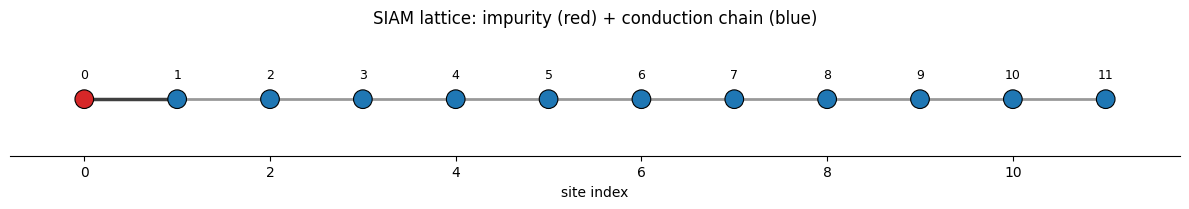

In [6]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## 6) 严格对角化（ED）

参照 `lattice-fermions.ipynb` 的思路：先把哈密顿量转为稀疏矩阵，再用 `scipy.sparse.linalg.eigsh` 求低能本征值。

注意：对 10 个 site 的自旋费米子，若不固定粒子数，Hilbert 空间仍可能较大。这里在固定粒子数扇区做严格对角化。

In [7]:
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# 直接复用第 3 段已构造好的 H（其 Hilbert 空间已固定粒子数）
N_up_ed, N_dn_ed = N_up, N_dn
sector_dim = comb(n_orbitals, N_up_ed) * comb(n_orbitals, N_dn_ed)
max_dim_for_sparse_ed = 2000000  # 经验阈值，可按机器内存调整

print("ED sector (N_up, N_dn) =", (N_up_ed, N_dn_ed))
print("Estimated Hilbert dimension =", sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    print(
        "[Skip ED] 该扇区维度过大，不执行 to_sparse()/eigsh 以避免内存溢出。"
    )
    print("建议: 减小粒子数（如 1,1 或 2,2）后再做严格对角化。")
else:
    H_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    sp_h = H_ed.to_sparse()
    eig_vals, eig_vecs = eigsh(sp_h, k=4, which="SA")
    eig_vals = np.sort(np.real(eig_vals))

    print("Hilbert dimension in this sector =", sp_h.shape[0])
    print("Exact ground-state energy E0 =", eig_vals[0])
    print("Lowest 4 eigenvalues =", eig_vals)

ED sector (N_up, N_dn) = (6, 6)
Estimated Hilbert dimension = 853776
Hilbert dimension in this sector = 853776
Exact ground-state energy E0 = -14.893010003461356
Lowest 4 eigenvalues = [-14.89301    -14.55691759 -14.36939923 -14.15038452]


## 7) 变分波函数优化（对齐 lattice-fermions 教程的完整流程）

下面依次实现并优化三类变分波函数：

1. Slater 行列式
2. Neural Jastrow-Slater
3. Neural Backflow

说明：以下文字推导与代码结构参考 tutorial，但已按 SIAM（含自旋）场景改写为等价表述。

In [8]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from functools import partial

from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# 如果第 6 段已执行，则直接复用基准能量；否则临时算一次（用于后续误差对比）
if "eig_vals" in globals():
    E_gs = float(np.sort(np.real(eig_vals))[0])
else:
    H_ref = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    from scipy.sparse.linalg import eigsh
    ref_vals, _ = eigsh(H_ref.to_sparse(), k=2, which="SA")
    E_gs = float(np.sort(np.real(ref_vals))[0])

print("reference E_gs =", E_gs)
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = -14.893010003461356
sampler graph nodes/edges = 12 11
seeds: (11, 101, 22, 202, 33, 303)


### 7.1 Slater 行列式

对固定粒子数费米体系，Slater 态可写为占据轨道子矩阵行列式。优化目标是最小化
$ E(\theta)=\langle\Psi_\theta|H|\Psi_\theta\rangle/\langle\Psi_\theta|\Psi_\theta\rangle $。

这里采用与教程一致的 VMC+SR 框架。

In [9]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

model_slater = LogSlaterDeterminant(hi)
sa_slater = nk.sampler.MetropolisFermionHop(
    hi, graph=graph_sampler, spin_symmetric=True
 )
vstate_slater = nk.vqs.MCState(
    sa_slater,
    model_slater,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_SLATER,
    sampler_seed=SEED_SAMPLER_SLATER,
 )

op_slater = nk.optimizer.Sgd(learning_rate=0.05)
gs_slater = nk.driver.VMC_SR(
    H, op_slater, variational_state=vstate_slater, diag_shift=0.05, mode="real"
 )

slater_log = nk.logging.RuntimeLog()
gs_slater.run(n_iter=300, out=slater_log)

E_slater = vstate_slater.expect(H)
err_slater = abs((E_slater.mean - E_gs) / E_gs)
print(f"Slater optimized energy: {E_slater}")
print(f"Slater relative error  : {err_slater}")

Automatic SR implementation choice:  QGT


100%|██████████| 300/300 [01:37<00:00,  3.08it/s, Energy=-14.626-0.000j ± 0.015 [σ²=1.0e+00, R̂=1.001]]


Slater optimized energy: -14.588+0.000j ± 0.016 [σ²=1.0e+00, R̂=1.003]
Slater relative error  : 0.020467537352882936


### 7.2 Neural Jastrow-Slater

在 Slater 振幅外再乘一个神经网络 Jastrow 因子：
$ \log\Psi(\mathbf{n}) = \log\Phi_{\mathrm{Slater}}(\mathbf{n}) + J_\theta(\mathbf{n}) $.

它主要增强相关性描述（尤其是振幅模值部分）。

In [10]:
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        return log_slater + j

model_nj = LogNeuralJastrowSlater(hi, hidden_units=max(32, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
 )

op_nj = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj = nk.driver.VMC_SR(
    H, op_nj, variational_state=vstate_nj, diag_shift=0.05, mode="real"
 )

nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=300, out=nj_log)

E_nj = vstate_nj.expect(H)
err_nj = abs((E_nj.mean - E_gs) / E_gs)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")
print(f"Neural Jastrow-Slater relative error  : {err_nj}")

Automatic SR implementation choice:  QGT


100%|██████████| 300/300 [01:53<00:00,  2.65it/s, Energy=-14.8907+0.0000j ± 0.0015 [σ²=9.7e-03, R̂=1.001]]


Neural Jastrow-Slater optimized energy: -14.8908+0.0000j ± 0.0015 [σ²=8.4e-03, R̂=1.003]
Neural Jastrow-Slater relative error  : 0.00015011298596099705


### 7.3 Neural Backflow

Backflow 的思想是把 Slater 轨道矩阵推广为构型依赖：
$ M^{\mathrm{bf}}(\mathbf{n})=M+F_\theta(\mathbf{n})$ .

下面给出与教程同类型的“加性 backflow”实现：神经网络输出与轨道矩阵同形状的修正项。

In [11]:
class LogNeuralBackflow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        n_orb = self.hilbert.n_orbitals
        n_spin = self.hilbert.n_spin_subsectors
        nfs = self.hilbert.n_fermions_per_spin[0]

        # 限制型 HF 基轨道（所有自旋扇区共享）
        M = self.param(
            "M",
            nn.initializers.lecun_normal(),
            (n_orb, nfs),
            float,
        )

        # Backflow 网络：输出 (n_spin, n_orb, nfs)
        x = n.astype(jnp.float32)
        F = nn.Dense(self.hidden_units)(x)
        F = jax.nn.tanh(F)
        F = nn.Dense(n_spin * n_orb * nfs)(F)
        F = F.reshape(F.shape[:-1] + (n_spin, n_orb, nfs))

        @partial(jnp.vectorize, signature="(m),(s,o,f)->()")
        def log_bf(n_one, F_one):
            R = n_one.nonzero(size=self.hilbert.n_fermions)[0]
            log_det_sum = 0.0 + 0.0j
            i_start = 0

            for i, nf_i in enumerate(self.hilbert.n_fermions_per_spin):
                if nf_i == 0:
                    continue
                R_i = R[i_start : i_start + nf_i] - i * n_orb
                A_i = (M + F_one[i])[R_i]
                log_det_sum = log_det_sum + nk.jax.logdet_cmplx(A_i)
                i_start += nf_i

            return log_det_sum

        return log_bf(n, F)

model_bf = LogNeuralBackflow(hi, hidden_units=max(32, 2 * n_orbitals))
sa_bf = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_bf = nk.vqs.MCState(
    sa_bf,
    model_bf,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_BF,
    sampler_seed=SEED_SAMPLER_BF,
 )

op_bf = nk.optimizer.Sgd(learning_rate=0.05)
gs_bf = nk.driver.VMC_SR(
    H, op_bf, variational_state=vstate_bf, diag_shift=0.05, mode="real"
 )

bf_log = nk.logging.RuntimeLog()
gs_bf.run(n_iter=300, out=bf_log)

E_bf = vstate_bf.expect(H)
err_bf = abs((E_bf.mean - E_gs) / E_gs)
print(f"Neural Backflow optimized energy: {E_bf}")
print(f"Neural Backflow relative error  : {err_bf}")

Automatic SR implementation choice:  NTK


100%|██████████| 300/300 [09:26<00:00,  1.89s/it, Energy=-14.8911-0.0000j ± 0.0012 [σ²=6.4e-03, R̂=1.002]]


Neural Backflow optimized energy: -14.8914-0.0000j ± 0.0018 [σ²=1.1e-02, R̂=1.004]
Neural Backflow relative error  : 0.00010559879864045702


### 7.4 结果汇总作图

和教程相同，把三种 ansatz 的优化能量曲线放在一张图中，并与 ED 基准能量比较。

### 扫描说明

- **用途**：扫描不同 `hidden_units` 下的 Neural Jastrow 与 Neural Backflow 的最终能量，并在同一张图中比较。
- **可调参数**：在代码单元中修改 `hidden_list`、`n_iter_scan`、`n_samples_scan` 以控制精度与运行时间。
- **运行提示**：每个配置会进行简化的 VMC 优化，可能耗时较长；建议先用较小的 `hidden_list` 和 `n_iter_scan` 进行快速试验。
- **输出**：绘制 `Energy vs hidden units` 曲线，并标注 ED 精确能量与 Slater 参考线（若可用）。


In [16]:
import netket as nk
import numpy as np

# 扫描不同 hidden units 下的 Neural Jastrow (NJ) 与 Neural Backflow (BF)
hidden_list = [8, 16, 32, 64, 128]
n_iter_scan = 150
n_samples_scan = 2**12

# 扩展 results 字典，增加存储历史数据和参数量的键
results = {
    'hidden': [], 
    'nj_energy': [], 
    'bf_energy': [],
    'nj_histories': [], # 存储 NJ 每一步的能量均值
    'bf_histories': [], # 存储 BF 每一步的能量均值
    'nj_params': [],    # 存储 NJ 参数量
    'bf_params': []     # 存储 BF 参数量
}

for h in hidden_list:
    print(f'== hidden_units = {h} ==')
    
    # --- Neural Jastrow ---
    try:
        model_nj_scan = LogNeuralJastrowSlater(hi, hidden_units=h)
        sa_nj_scan = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
        vstate_nj_scan = nk.vqs.MCState(sa_nj_scan, model_nj_scan, n_samples=n_samples_scan, n_discard_per_chain=16, seed=SEED_MODEL_NJ + h, sampler_seed=SEED_SAMPLER_NJ + h)
        
        # 记录参数量
        nj_p = vstate_nj_scan.n_parameters
        results['nj_params'].append(nj_p)
        print(f" [NJ] Params: {nj_p}")

        opt_nj = nk.optimizer.Sgd(learning_rate=0.05)
        # 创建 Logger
        log_nj = nk.logging.RuntimeLog()
        driver_nj = nk.driver.VMC_SR(H, opt_nj, variational_state=vstate_nj_scan, diag_shift=0.05, mode='real')
        
        # 传入 out=log_nj 来记录历史
        driver_nj.run(n_iter=n_iter_scan, out=log_nj)
        
        # 提取历史能量均值
        results['nj_histories'].append(log_nj.data['Energy']['Mean'])
        
        E_nj_scan = vstate_nj_scan.expect(H)
        nj_val = float(E_nj_scan.mean.real)
    except Exception as e:
        print('NJ scan failed for h=', h, '->', e)
        nj_val = float('nan')
        results['nj_histories'].append([])
        results['nj_params'].append(0)

    # --- Neural Backflow ---
    try:
        model_bf_scan = LogNeuralBackflow(hi, hidden_units=h)
        sa_bf_scan = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
        vstate_bf_scan = nk.vqs.MCState(sa_bf_scan, model_bf_scan, n_samples=n_samples_scan, n_discard_per_chain=16, seed=SEED_MODEL_BF + h, sampler_seed=SEED_SAMPLER_BF + h)
        
        # 记录参数量
        bf_p = vstate_bf_scan.n_parameters
        results['bf_params'].append(bf_p)
        print(f" [BF] Params: {bf_p}")

        opt_bf = nk.optimizer.Sgd(learning_rate=0.05)
        # 创建 Logger
        log_bf = nk.logging.RuntimeLog()
        driver_bf = nk.driver.VMC_SR(H, opt_bf, variational_state=vstate_bf_scan, diag_shift=0.05, mode='real')
        
        # 传入 out=log_bf 来记录历史
        driver_bf.run(n_iter=n_iter_scan, out=log_bf)
        
        # 提取历史能量均值
        results['bf_histories'].append(log_bf.data['Energy']['Mean'])
        
        E_bf_scan = vstate_bf_scan.expect(H)
        bf_val = float(E_bf_scan.mean.real)
    except Exception as e:
        print('BF scan failed for h=', h, '->', e)
        bf_val = float('nan')
        results['bf_histories'].append([])
        results['bf_params'].append(0)

    results['hidden'].append(h)
    results['nj_energy'].append(nj_val)
    results['bf_energy'].append(bf_val)


== hidden_units = 8 ==
 [NJ] Params: 281
Automatic SR implementation choice:  QGT


100%|██████████| 150/150 [00:55<00:00,  2.71it/s, Energy=-14.8909+0.0000j ± 0.0014 [σ²=6.9e-03, R̂=1.002]]


 [BF] Params: 1568
Automatic SR implementation choice:  QGT


100%|██████████| 150/150 [01:13<00:00,  2.03it/s, Energy=-14.8909+0.0000j ± 0.0020 [σ²=1.5e-02, R̂=1.001]]


== hidden_units = 16 ==
 [NJ] Params: 489
Automatic SR implementation choice:  QGT


...

100%|██████████| 150/150 [05:17<00:00,  2.11s/it, Energy=-14.8779+0.0000j ± 0.0042 [σ²=7.2e-02, R̂=1.000]]


== hidden_units = 128 ==
 [NJ] Params: 3401
Automatic SR implementation choice:  QGT


100%|██████████| 150/150 [01:56<00:00,  1.29it/s, Energy=-14.8888-0.0000j ± 0.0015 [σ²=9.4e-03, R̂=1.002]]


 [BF] Params: 21848
Automatic SR implementation choice:  NTK


100%|██████████| 150/150 [06:51<00:00,  2.74s/it, Energy=-14.8677-0.0000j ± 0.0045 [σ²=8.2e-02, R̂=1.001]]


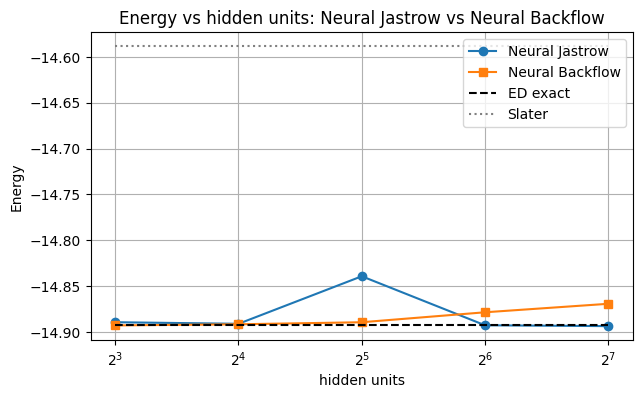

In [17]:
# 绘图：在同一张图中显示 NJ 与 BF 的能量随 hidden units 的变化，并标注 ED 与 Slater 基线
from matplotlib import pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(results['hidden'], results['nj_energy'], '-o', label='Neural Jastrow')
plt.plot(results['hidden'], results['bf_energy'], '-s', label='Neural Backflow')
plt.hlines(E_gs, xmin=min(results['hidden']), xmax=max(results['hidden']), colors='k', linestyles='--', label='ED exact')
# 如果 Slater 能量存在，则绘制为参考线（可能之前已计算）
try:
    slater_val = float(E_slater.mean.real)
    plt.hlines(slater_val, xmin=min(results['hidden']), xmax=max(results['hidden']), colors='gray', linestyles=':', label='Slater')
except Exception:
    pass

plt.xscale('log', base=2)
plt.xlabel('hidden units')
plt.ylabel('Energy')
plt.title('Energy vs hidden units: Neural Jastrow vs Neural Backflow')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


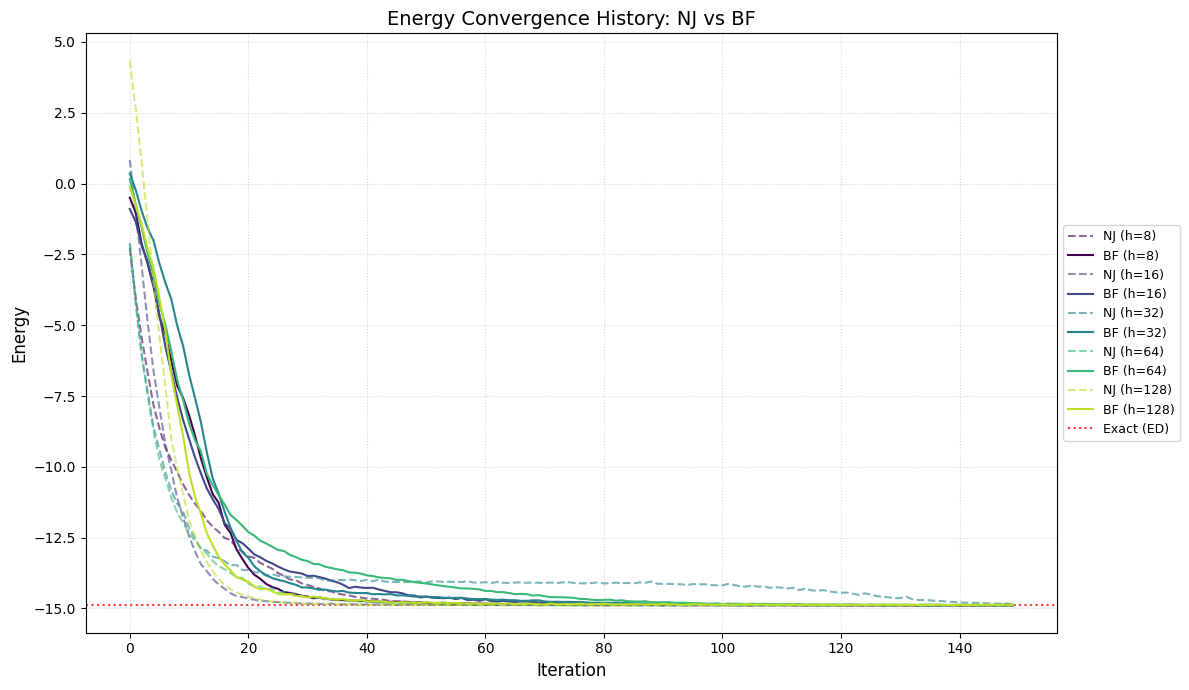

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 设置画布
plt.figure(figsize=(12, 7))

# 使用 colormap 生成一组颜色，确保不同 hidden units 之间有区分度
colors = plt.cm.viridis(np.linspace(0, 0.9, len(hidden_list)))

# 假设你在循环中已经将历史数据存入 results['nj_histories'] = [array1, array2, ...]
# 如果你使用的是 NetKet 的 JsonLog 或 RuntimeLog，数据通常在 logger.data['Energy']['Mean']
for i, h in enumerate(hidden_list):
    # 绘制 Neural Jastrow 的收敛曲线 (虚线)
    if 'nj_histories' in results and i < len(results['nj_histories']):
        y_nj = results['nj_histories'][i]
        plt.plot(y_nj, color=colors[i], linestyle='--', alpha=0.6, 
                 label=f'NJ (h={h})')
    
    # 绘制 Neural Backflow 的收敛曲线 (实线)
    if 'bf_histories' in results and i < len(results['bf_histories']):
        y_bf = results['bf_histories'][i]
        plt.plot(y_bf, color=colors[i], linestyle='-', linewidth=1.5,
                 label=f'BF (h={h})')

# 绘制 ED 精确能量参考线
if 'E_gs' in locals():
    plt.axhline(y=E_gs, color='red', linestyle=':', label='Exact (ED)', alpha=0.8, zorder=0)

# 图表修饰
plt.title('Energy Convergence History: NJ vs BF', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Energy', fontsize=12)

# 将图例放在右侧，避免遮挡收敛曲线
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=9)

plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


In [19]:
import numpy as np

# 遍历 hidden_list，将每个配置的收敛历史保存为独立的 txt 文件
for i, h in enumerate(results['hidden']):
    # --- 保存 Neural Jastrow (NJ) 历史 ---
    nj_history = results['nj_histories'][i]
    if len(nj_history) > 0:
        filename_nj = f"energy_history_nj_h{h}.txt"
        # 构造数据：第一列是迭代步数，第二列是能量均值
        # 注意：使用 .real 确保保存的是实部
        iters = np.arange(len(nj_history))
        data_nj = np.column_stack((iters, np.array(nj_history).real))
        
        # 保存文件，fmt 指定格式（整数步数，10位小数能量）
        np.savetxt(filename_nj, data_nj, fmt='%d %.10f', 
                   header=f"NJ hidden_units={h}\nIteration Energy_Mean")
        print(f"已保存: {filename_nj}")

    # --- 保存 Neural Backflow (BF) 历史 ---
    bf_history = results['bf_histories'][i]
    if len(bf_history) > 0:
        filename_bf = f"energy_history_bf_h{h}.txt"
        iters = np.arange(len(bf_history))
        data_bf = np.column_stack((iters, np.array(bf_history).real))
        
        np.savetxt(filename_bf, data_bf, fmt='%d %.10f', 
                   header=f"BF hidden_units={h}\nIteration Energy_Mean")
        print(f"已保存: {filename_bf}")

# --- 额外步骤：保存一个汇总所有 hidden units 最终能量的摘要文件 ---
summary_file = "summary_results.txt"
# 准备汇总数据
summary_table = np.column_stack((
    results['hidden'],
    results['nj_params'],
    results['nj_energy'],
    results['bf_params'],
    results['bf_energy']
))

np.savetxt(summary_file, summary_table, fmt='%d %d %.10f %d %.10f',
           header="Hidden_Units NJ_Params NJ_Energy BF_Params BF_Energy")
print(f"\n所有配置的最终结果已汇总至: {summary_file}")


已保存: energy_history_nj_h8.txt
已保存: energy_history_bf_h8.txt
已保存: energy_history_nj_h16.txt
已保存: energy_history_bf_h16.txt
已保存: energy_history_nj_h32.txt
已保存: energy_history_bf_h32.txt
已保存: energy_history_nj_h64.txt
已保存: energy_history_bf_h64.txt
已保存: energy_history_nj_h128.txt
已保存: energy_history_bf_h128.txt

所有配置的最终结果已汇总至: summary_results.txt


C:\Users\10783\AppData\Local\Temp\ipykernel_19224\4101297950.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


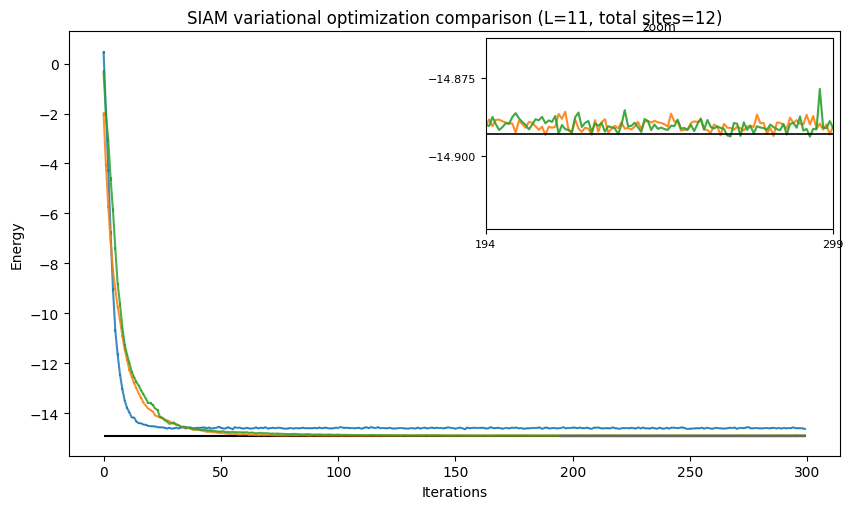

In [20]:
logged_data = (slater_log.data, nj_log.data, bf_log.data)
labels = ("Slater", "Neural Jastrow", "Neural Backflow")

from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(8.6, 5.2))
for data, label in zip(logged_data, labels):
    ax.errorbar(
        data["Energy"].iters,
        data["Energy"].Mean.real,
        yerr=data["Energy"].Sigma,
        label=label,
        alpha=0.85,
    )

iters_max = max(data["Energy"].iters[-1] for data in logged_data)
ax.hlines([E_gs], xmin=0, xmax=iters_max, color="black", label="ED Exact")

ax.set_xlabel("Iterations")
ax.set_ylabel("Energy")
ax.legend()
ax.set_title(f"SIAM variational optimization comparison (L={L}, total sites={n_orbitals})")

# inset: 放大末段迭代与接近 E_gs 的能量窗口
axins = inset_axes(ax, width="45%", height="45%", loc="upper right")
for data, _label in zip(logged_data, labels):
    axins.plot(data["Energy"].iters, data["Energy"].Mean.real, alpha=0.9)
axins.hlines([E_gs], xmin=0, xmax=iters_max, color="black", linewidth=1.2)

# 自动设置放大窗口（后 35% 迭代 + 更窄的 E_gs 邻域）
x1 = int(0.65 * iters_max)
x2 = int(iters_max)
all_means = np.concatenate([np.asarray(d["Energy"].Mean.real) for d in logged_data])
y_center = E_gs
y_span = max(1e-6, 0.002 * np.max(np.abs(all_means - y_center)))
axins.set_xlim(x1, x2)
axins.set_ylim(y_center - y_span, y_center + y_span)
axins.set_xticks([x1, x2])

# 打开并设置 inset 的 y 轴刻度
axins.yaxis.set_major_locator(MaxNLocator(nbins=3))
axins.tick_params(axis="y", labelsize=8)
axins.tick_params(axis="x", labelsize=8)
axins.set_title("zoom", fontsize=9)

# 使用 matplotlib 原生接口标注放大区域，连线更规整
ax.indicate_inset_zoom(axins, edgecolor="0.4", alpha=0.9)

plt.tight_layout()
plt.show()